In [16]:
# Vivi Lazo
# Took 12.45 minutes to fully run on 12th Gen i5-12600KF CPU + Radeon RX 6700 GPU machine with 32GB RAM and 12 GB of VRAM

In [1]:
import albumentations as A
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader
from albumentations.pytorch import ToTensorV2
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder

from auxiliary.model_utils import *
from auxiliary.cnn_class import CNN
from auxiliary.pokemon_dataset import PokemonDataset
from auxiliary.numpy_dataset import NumpyDataset

In [2]:
DATA_DIR    = "Pokemon"
IMG_SIZE    = (64, 64)
BATCH_SIZE  = 32
EPOCHS      = 50
LR          = 1e-3
N_FOLDS     = 5
RANDOM_SEED = 1996
DEVICE      = "cuda" if torch.cuda.is_available() else "cpu"
 
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
print(f"Using device: {DEVICE}")


Using device: cuda


In [3]:
train_transform = A.Compose([
    A.Resize(64, 64),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.2),
    A.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Resize(64, 64),
    A.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)),
    ToTensorV2()
])

# Run with cleaned images (5 aug)

In [4]:
# 1. Load the .npy files
x_train_5aug = np.load('./Pokemon/X_train_5aug.npy')
y_train_5aug = np.load('./Pokemon/y_train_5aug.npy')

x_val_5aug = np.load('./Pokemon/X_val_5aug.npy')
y_val_5aug = np.load('./Pokemon/y_val_5aug.npy')

x_test_5aug = np.load('./Pokemon/X_test_5aug.npy')
y_test_5aug = np.load('./Pokemon/y_test_5aug.npy')

le = LabelEncoder()
y_train_idx_5aug = le.fit_transform(y_train_5aug)  
y_val_idx_5aug   = le.transform(y_val_5aug)        
y_test_idx_5aug  = le.transform(y_test_5aug)

# Save the class names for later plotting
class_names = le.classes_
print(f"Detected {len(class_names)} classes: {class_names}")

Detected 151 classes: ['abra' 'aerodactyl' 'alakazam' 'arbok' 'arcanine' 'articuno' 'beedrill'
 'bellsprout' 'blastoise' 'bulbasaur' 'butterfree' 'caterpie' 'chansey'
 'charizard' 'charmander' 'charmeleon' 'clefable' 'clefairy' 'cloyster'
 'cubone' 'dewgong' 'diglett' 'ditto' 'dodrio' 'doduo' 'dragonair'
 'dragonite' 'dratini' 'drowzee' 'dugtrio' 'eevee' 'ekans' 'electabuzz'
 'electrode' 'exeggcute' 'exeggutor' "farfetch'd" 'fearow' 'flareon'
 'gastly' 'gengar' 'geodude' 'gloom' 'golbat' 'goldeen' 'golduck' 'golem'
 'graveler' 'grimer' 'growlithe' 'gyarados' 'haunter' 'hitmonchan'
 'hitmonlee' 'horsea' 'hypno' 'ivysaur' 'jigglypuff' 'jolteon' 'jynx'
 'kabuto' 'kabutops' 'kadabra' 'kakuna' 'kangaskhan' 'kingler' 'koffing'
 'krabby' 'lapras' 'lickitung' 'machamp' 'machoke' 'machop' 'magikarp'
 'magmar' 'magnemite' 'magneton' 'mankey' 'marowak' 'meowth' 'metapod'
 'mew' 'mewtwo' 'moltres' 'mr mime' 'muk' 'nidoking' 'nidoqueen'
 'nidoran♀' 'nidoran♂' 'nidorina' 'nidorino' 'ninetales' 'oddi

In [5]:
train_loader_5aug = DataLoader(NumpyDataset(x_train_5aug, y_train_idx_5aug, transform=train_transform), 
                          batch_size=BATCH_SIZE, shuffle=True)
val_loader_5aug   = DataLoader(NumpyDataset(x_val_5aug, y_val_idx_5aug, transform=val_transform), 
                          batch_size=BATCH_SIZE, shuffle=False)
test_loader_5aug  = DataLoader(NumpyDataset(x_test_5aug, y_test_idx_5aug, transform=val_transform), 
                          batch_size=BATCH_SIZE, shuffle=False)

In [6]:
# Initialize Model
model_5aug = CNN(num_classes=len(le.classes_)).to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model_5aug.parameters(), lr=1e-4, weight_decay=0.01)

# Dictionary to store history for plotting
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

for epoch in range(1, EPOCHS + 1):
    model_5aug.train()
    train_loss, train_correct = 0, 0
    
    for images, labels in train_loader_5aug:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        
        optimizer.zero_grad()
        outputs = model_5aug(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item() * images.size(0)
        train_correct += (outputs.argmax(1) == labels).sum().item()
    
    # Validation
    model_5aug.eval()
    val_loss, val_correct = 0, 0
    with torch.no_grad():
        for images, labels in val_loader_5aug:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model_5aug(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)
            val_correct += (outputs.argmax(1) == labels).sum().item()
            
    # Calculate averages
    metrics = {
        "train_loss": train_loss / len(x_train_5aug),
        "train_acc":  train_correct / len(x_train_5aug),
        "val_loss":   val_loss / len(x_val_5aug),
        "val_acc":    val_correct / len(x_val_5aug)
    }
    
    for key in history: history[key].append(metrics[key])
    
    print(f"Epoch {epoch:02d}/{EPOCHS} | Train Loss: {metrics['train_loss']:.4f} Acc: {metrics['train_acc']:.4f} | "
          f"Val Loss: {metrics['val_loss']:.4f} Acc: {metrics['val_acc']:.4f}")

Detected flattened size: 8192


/home/viviteto/miniforge3/envs/ml_env/lib/python3.12/site-packages/torch/nn/modules/linear.py:125: UserWarning: Attempting to use hipBLASLt on an unsupported architecture! Overriding blas backend to hipblas (Triggered internally at ../aten/src/ATen/Context.cpp:296.)
  return F.linear(input, self.weight, self.bias)


Epoch 01/50 | Train Loss: 4.6924 Acc: 0.0397 | Val Loss: 3.9462 Acc: 0.1416
Epoch 02/50 | Train Loss: 3.8198 Acc: 0.1490 | Val Loss: 3.2050 Acc: 0.2740
Epoch 03/50 | Train Loss: 3.2595 Acc: 0.2455 | Val Loss: 2.8939 Acc: 0.3386
Epoch 04/50 | Train Loss: 2.8494 Acc: 0.3223 | Val Loss: 2.6547 Acc: 0.3858
Epoch 05/50 | Train Loss: 2.5254 Acc: 0.3853 | Val Loss: 2.4623 Acc: 0.4263
Epoch 06/50 | Train Loss: 2.2877 Acc: 0.4313 | Val Loss: 2.3867 Acc: 0.4421
Epoch 07/50 | Train Loss: 2.0676 Acc: 0.4807 | Val Loss: 2.3000 Acc: 0.4801
Epoch 08/50 | Train Loss: 1.8744 Acc: 0.5206 | Val Loss: 2.2722 Acc: 0.4851
Epoch 09/50 | Train Loss: 1.7211 Acc: 0.5533 | Val Loss: 2.2131 Acc: 0.5041
Epoch 10/50 | Train Loss: 1.5934 Acc: 0.5831 | Val Loss: 2.2164 Acc: 0.5091
Epoch 11/50 | Train Loss: 1.4572 Acc: 0.6140 | Val Loss: 2.2174 Acc: 0.5033
Epoch 12/50 | Train Loss: 1.3579 Acc: 0.6331 | Val Loss: 2.1716 Acc: 0.5273
Epoch 13/50 | Train Loss: 1.2520 Acc: 0.6605 | Val Loss: 2.2203 Acc: 0.5389
Epoch 14/50 

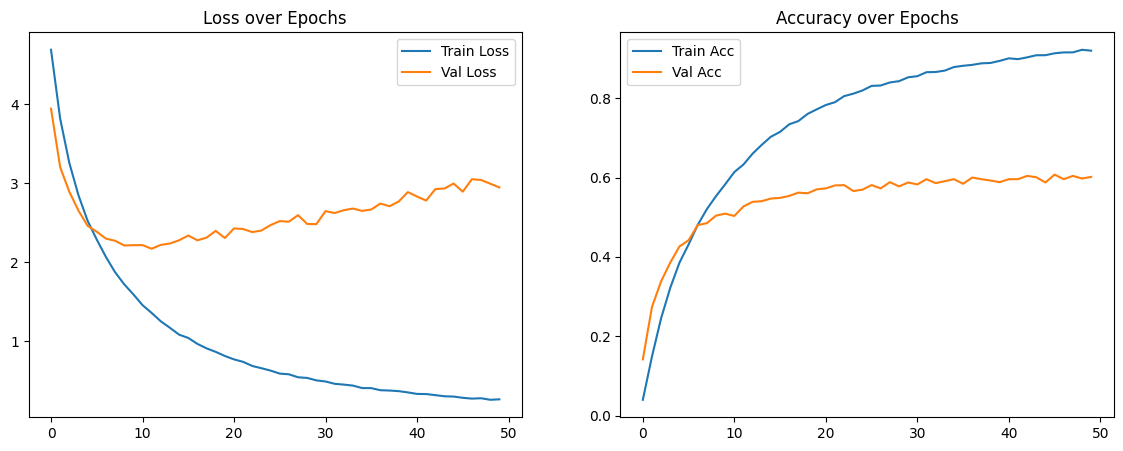

In [7]:
# 1. Plot Training/Validation Curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history["train_loss"], label="Train Loss")
ax1.plot(history["val_loss"], label="Val Loss")
ax1.set_title("Loss over Epochs")
ax1.legend()

ax2.plot(history["train_acc"], label="Train Acc")
ax2.plot(history["val_acc"], label="Val Acc")
ax2.set_title("Accuracy over Epochs")
ax2.legend()

plt.show()

In [73]:
# 2. Final Evaluation on Test Set
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import torch.nn.functional as F

model_5aug.eval()
all_preds = []
all_labels = []
all_probs = [] # Needed for ROC-AUC

with torch.no_grad():
    for images, labels in test_loader_5aug:
        images = images.to(DEVICE)
        outputs = model_5aug(images)
        
        # Get probabilities using Softmax
        probs = F.softmax(outputs, dim=1)
        
        all_probs.extend(probs.cpu().numpy())
        all_preds.extend(outputs.argmax(1).cpu().numpy())
        all_labels.extend(labels.numpy())

# 1. Precision, Recall, and F1-score
# These are all included in the classification_report
print("--- Detailed Classification Report ---")
# target_names uses the labels from your LabelEncoder
display_report = classification_report(all_labels, all_preds, target_names=le.classes_)
report_5aug = classification_report(all_labels, all_preds, target_names=le.classes_, output_dict=True)
print(display_report)

# 2. ROC-AUC Score
# For multi-class, we must specify multi_class='ovr' (One-vs-Rest)
# and 'macro' or 'weighted' averaging.
roc_auc_ovr_5aug = roc_auc_score(
    all_labels, 
    all_probs, 
    multi_class='ovr', 
    average='macro'
)

print(f"ROC-AUC Score (One-vs-Rest, Macro): {roc_auc_ovr_5aug:.4f}")

--- Detailed Classification Report ---
              precision    recall  f1-score   support

        abra       0.40      0.75      0.52         8
  aerodactyl       0.64      0.88      0.74         8
    alakazam       0.64      0.88      0.74         8
       arbok       0.45      0.62      0.53         8
    arcanine       0.67      0.75      0.71         8
    articuno       0.67      0.75      0.71         8
    beedrill       0.67      0.50      0.57         8
  bellsprout       0.57      0.50      0.53         8
   blastoise       0.56      0.62      0.59         8
   bulbasaur       0.62      0.62      0.62         8
  butterfree       1.00      0.75      0.86         8
    caterpie       0.83      0.62      0.71         8
     chansey       0.83      0.62      0.71         8
   charizard       0.89      1.00      0.94         8
  charmander       0.50      0.38      0.43         8
  charmeleon       0.62      0.62      0.62         8
    clefable       0.75      0.75      0.7

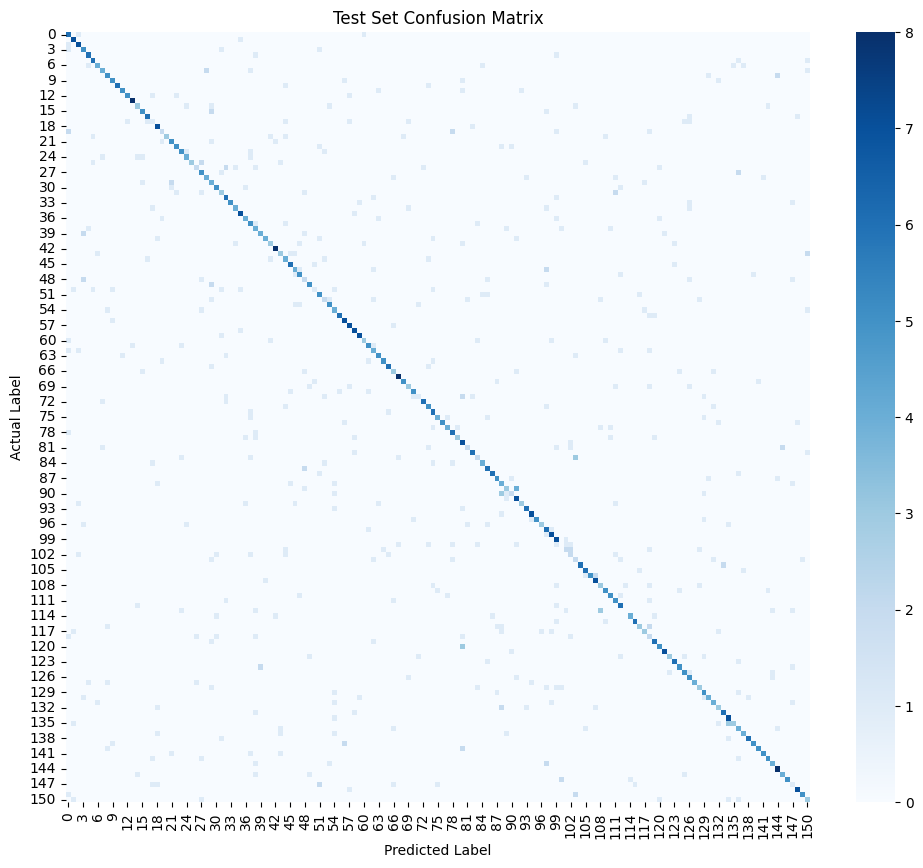

In [9]:
# 3. Confusion Matrix for Test Set
plt.figure(figsize=(12, 10))
sns.heatmap(confusion_matrix(all_labels, all_preds), annot=False, fmt='d', cmap='Blues')
plt.title("Test Set Confusion Matrix")
plt.ylabel("Actual Label")
plt.xlabel("Predicted Label")
plt.show()

# Run with cleaned images (10 aug)

In [10]:
# 1. Load the .npy files
x_train_10aug = np.load('./Pokemon/X_train_10aug.npy')
y_train_10aug = np.load('./Pokemon/y_train_10aug.npy')

x_val_10aug = np.load('./Pokemon/X_val_10aug.npy')
y_val_10aug = np.load('./Pokemon/y_val_10aug.npy')

x_test_10aug = np.load('./Pokemon/X_test_10aug.npy')
y_test_10aug = np.load('./Pokemon/y_test_10aug.npy')

le = LabelEncoder()
y_train_idx_10aug = le.fit_transform(y_train_10aug)  
y_val_idx_10aug   = le.transform(y_val_10aug)        
y_test_idx_10aug  = le.transform(y_test_10aug)

# Save the class names for later plotting
class_names = le.classes_
print(f"Detected {len(class_names)} classes: {class_names}")

Detected 151 classes: ['abra' 'aerodactyl' 'alakazam' 'arbok' 'arcanine' 'articuno' 'beedrill'
 'bellsprout' 'blastoise' 'bulbasaur' 'butterfree' 'caterpie' 'chansey'
 'charizard' 'charmander' 'charmeleon' 'clefable' 'clefairy' 'cloyster'
 'cubone' 'dewgong' 'diglett' 'ditto' 'dodrio' 'doduo' 'dragonair'
 'dragonite' 'dratini' 'drowzee' 'dugtrio' 'eevee' 'ekans' 'electabuzz'
 'electrode' 'exeggcute' 'exeggutor' "farfetch'd" 'fearow' 'flareon'
 'gastly' 'gengar' 'geodude' 'gloom' 'golbat' 'goldeen' 'golduck' 'golem'
 'graveler' 'grimer' 'growlithe' 'gyarados' 'haunter' 'hitmonchan'
 'hitmonlee' 'horsea' 'hypno' 'ivysaur' 'jigglypuff' 'jolteon' 'jynx'
 'kabuto' 'kabutops' 'kadabra' 'kakuna' 'kangaskhan' 'kingler' 'koffing'
 'krabby' 'lapras' 'lickitung' 'machamp' 'machoke' 'machop' 'magikarp'
 'magmar' 'magnemite' 'magneton' 'mankey' 'marowak' 'meowth' 'metapod'
 'mew' 'mewtwo' 'moltres' 'mr mime' 'muk' 'nidoking' 'nidoqueen'
 'nidoran♀' 'nidoran♂' 'nidorina' 'nidorino' 'ninetales' 'oddi

In [11]:
train_loader_10aug = DataLoader(NumpyDataset(x_train_10aug, y_train_idx_10aug, transform=train_transform), 
                          batch_size=BATCH_SIZE, shuffle=True)
val_loader_10aug   = DataLoader(NumpyDataset(x_val_10aug, y_val_idx_10aug, transform=val_transform), 
                          batch_size=BATCH_SIZE, shuffle=False)
test_loader_10aug  = DataLoader(NumpyDataset(x_test_10aug, y_test_idx_10aug, transform=val_transform), 
                          batch_size=BATCH_SIZE, shuffle=False)

In [12]:
# Initialize Model
model_10aug = CNN(num_classes=len(le.classes_)).to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model_10aug.parameters(), lr=1e-4, weight_decay=0.01)

# Dictionary to store history for plotting
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

for epoch in range(1, EPOCHS + 1):
    model_10aug.train()
    train_loss, train_correct = 0, 0
    
    for images, labels in train_loader_10aug:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        
        optimizer.zero_grad()
        outputs = model_10aug(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item() * images.size(0)
        train_correct += (outputs.argmax(1) == labels).sum().item()
    
    # Validation
    model_10aug.eval()
    val_loss, val_correct = 0, 0
    with torch.no_grad():
        for images, labels in val_loader_10aug:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model_10aug(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)
            val_correct += (outputs.argmax(1) == labels).sum().item()
            
    # Calculate averages
    metrics = {
        "train_loss": train_loss / len(x_train_10aug),
        "train_acc":  train_correct / len(x_train_10aug),
        "val_loss":   val_loss / len(x_val_10aug),
        "val_acc":    val_correct / len(x_val_10aug)
    }
    
    for key in history: history[key].append(metrics[key])
    
    print(f"Epoch {epoch:02d}/{EPOCHS} | Train Loss: {metrics['train_loss']:.4f} Acc: {metrics['train_acc']:.4f} | "
          f"Val Loss: {metrics['val_loss']:.4f} Acc: {metrics['val_acc']:.4f}")

Detected flattened size: 8192
Epoch 01/50 | Train Loss: 4.5252 Acc: 0.0555 | Val Loss: 3.4282 Acc: 0.2235
Epoch 02/50 | Train Loss: 3.6027 Acc: 0.1893 | Val Loss: 2.7957 Acc: 0.3593
Epoch 03/50 | Train Loss: 3.0726 Acc: 0.2892 | Val Loss: 2.4557 Acc: 0.4396
Epoch 04/50 | Train Loss: 2.7082 Acc: 0.3609 | Val Loss: 2.2940 Acc: 0.4627
Epoch 05/50 | Train Loss: 2.4297 Acc: 0.4141 | Val Loss: 2.1615 Acc: 0.5008
Epoch 06/50 | Train Loss: 2.1887 Acc: 0.4671 | Val Loss: 2.0868 Acc: 0.5232
Epoch 07/50 | Train Loss: 2.0002 Acc: 0.5108 | Val Loss: 2.0261 Acc: 0.5414
Epoch 08/50 | Train Loss: 1.8467 Acc: 0.5431 | Val Loss: 2.0516 Acc: 0.5406
Epoch 09/50 | Train Loss: 1.7254 Acc: 0.5713 | Val Loss: 2.0241 Acc: 0.5604
Epoch 10/50 | Train Loss: 1.6007 Acc: 0.5962 | Val Loss: 2.0061 Acc: 0.5596
Epoch 11/50 | Train Loss: 1.4973 Acc: 0.6197 | Val Loss: 1.9903 Acc: 0.5770
Epoch 12/50 | Train Loss: 1.4162 Acc: 0.6408 | Val Loss: 2.0084 Acc: 0.5737
Epoch 13/50 | Train Loss: 1.3437 Acc: 0.6581 | Val Loss: 2

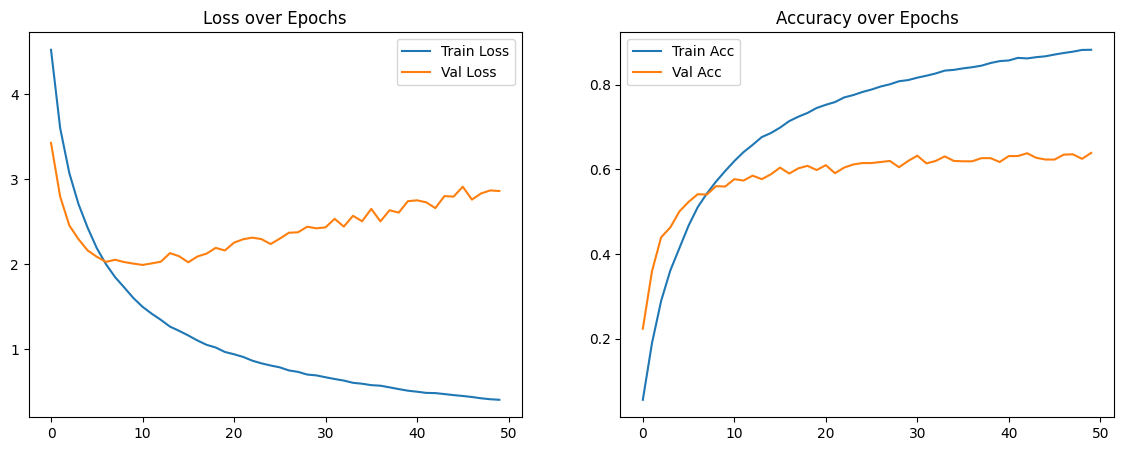

In [13]:
# 1. Plot Training/Validation Curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history["train_loss"], label="Train Loss")
ax1.plot(history["val_loss"], label="Val Loss")
ax1.set_title("Loss over Epochs")
ax1.legend()

ax2.plot(history["train_acc"], label="Train Acc")
ax2.plot(history["val_acc"], label="Val Acc")
ax2.set_title("Accuracy over Epochs")
ax2.legend()

plt.show()

In [95]:
# 2. Final Evaluation on Test Set
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import torch.nn.functional as F

model_10aug.eval()
all_preds = []
all_labels = []
all_probs = [] # Needed for ROC-AUC

with torch.no_grad():
    for images, labels in test_loader_10aug:
        images = images.to(DEVICE)
        outputs = model_10aug(images)
        
        # Get probabilities using Softmax
        probs = F.softmax(outputs, dim=1)
        
        all_probs.extend(probs.cpu().numpy())
        all_preds.extend(outputs.argmax(1).cpu().numpy())
        all_labels.extend(labels.numpy())

# 1. Precision, Recall, and F1-score
# These are all included in the classification_report
print("--- Detailed Classification Report ---")
# target_names uses the labels from your LabelEncoder
display_report = classification_report(all_labels, all_preds, target_names=le.classes_)
report_10aug = classification_report(all_labels, all_preds, target_names=le.classes_, output_dict=True)

print(display_report)

# 2. ROC-AUC Score
# For multi-class, we must specify multi_class='ovr' (One-vs-Rest)
# and 'macro' or 'weighted' averaging.
roc_auc_ovr_10aug = roc_auc_score(
    all_labels, 
    all_probs, 
    multi_class='ovr', 
    average='macro'
)

print(f"ROC-AUC Score (One-vs-Rest, Macro): {roc_auc_ovr:.4f}")

--- Detailed Classification Report ---
              precision    recall  f1-score   support

        abra       0.45      0.62      0.53         8
  aerodactyl       0.78      0.88      0.82         8
    alakazam       0.57      1.00      0.73         8
       arbok       0.56      0.62      0.59         8
    arcanine       0.86      0.75      0.80         8
    articuno       0.47      0.88      0.61         8
    beedrill       1.00      0.75      0.86         8
  bellsprout       1.00      0.50      0.67         8
   blastoise       0.67      0.50      0.57         8
   bulbasaur       0.67      0.75      0.71         8
  butterfree       0.67      0.75      0.71         8
    caterpie       0.55      0.75      0.63         8
     chansey       0.62      0.62      0.62         8
   charizard       0.47      1.00      0.64         8
  charmander       0.58      0.88      0.70         8
  charmeleon       0.60      0.75      0.67         8
    clefable       0.70      0.88      0.7

In [111]:
# get metrics to use for model comparison
import csv

metrics = ['macro_avg', 'weighted_avg']
csv_headers = []
csv_contents = []
temp_row = []

for index, metric in enumerate(metrics):
    temp_metric = '_'.join(metric.split('_'))
    report_key = metric.replace('_', ' ')
    for key in report_5aug[report_key].keys():
        csv_headers.append(temp_metric + '_' + key)
        temp_row.append(report_5aug[report_key][key])

csv_contents.append(temp_row)

temp_row = []

for index, metric in enumerate(metrics):
    temp_metric = '_'.join(metric.split('_'))
    report_key = metric.replace('_', ' ')
    for key in report_10aug[report_key].keys():
        temp_row.append(report_10aug[report_key][key])

csv_contents.append(temp_row)

csv_headers.append('accuracy')
csv_headers.append('ROC-AUC')

csv_contents[0].append(report_5aug['accuracy'])
csv_contents[1].append(report_10aug['accuracy'])

csv_contents[0].append(roc_auc_ovr_5aug)
csv_contents[1].append(roc_auc_ovr_10aug)

with open('metrics.csv', 'w', newline='') as file:
    writer = csv.writer(file)
    writer.writerow(csv_headers)
    writer.writerows(csv_contents)

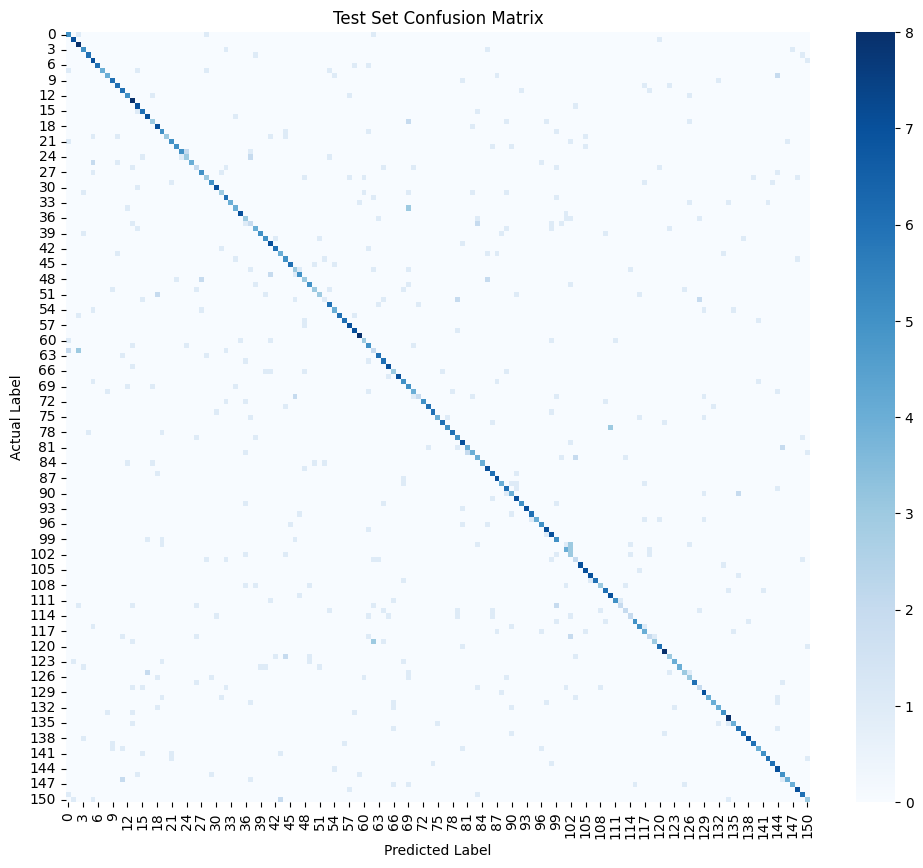

In [15]:
# 3. Confusion Matrix for Test Set
plt.figure(figsize=(12, 10))
sns.heatmap(confusion_matrix(all_labels, all_preds), annot=False, fmt='d', cmap='Blues')
plt.title("Test Set Confusion Matrix")
plt.ylabel("Actual Label")
plt.xlabel("Predicted Label")
plt.show()